In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as ss
import sqlite3
import shap

In [74]:
conn = sqlite3.connect(r"C:\Users\01\problem\database/project.db")

DATABSE CONNECTION

In [75]:
students = pd.read_excel(r"C:\Users\01\problem\dataset\data\previous\previous_year_student_master.xlsx")
attendance = pd.read_excel(r"C:\Users\01\problem\dataset\data\previous\previous_year_attendance_data.xlsx")
assessments = pd.read_excel(r"C:\Users\01\problem\dataset\data\previous\previous_year_assessment_data.xlsx")
fees = pd.read_excel(r"C:\Users\01\problem\dataset\data\previous\previous_year_fee_payment_data.xlsx")

In [76]:
students.to_sql("students",conn,if_exists="replace",index=False)
attendance.to_sql("attendance",conn,if_exists="replace",index=False)
assessments.to_sql("assessments",conn,if_exists="replace",index=False)
fees.to_sql("fees",conn,if_exists="replace",index=False)

2000

In [77]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",conn)

In [78]:
df = (students
    .merge(attendance, on="student_id", how="left")
    .merge(assessments, on="student_id", how="left")
    .merge(fees, on="student_id", how="left"))

EXPLORING DATA

In [79]:
df["target"] = (df["dropped_out"] == "Yes").astype(int)

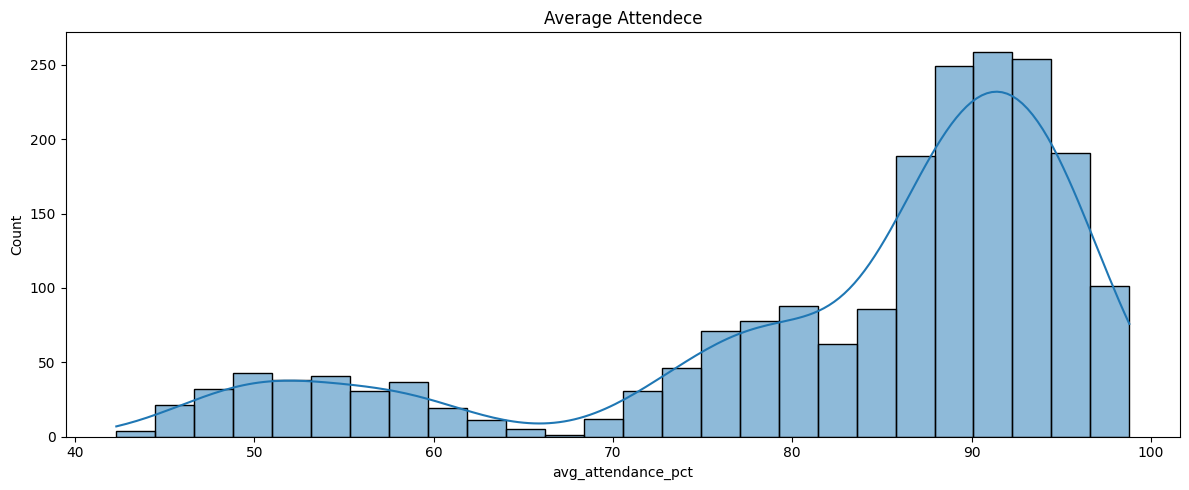

In [80]:
mp.figure(figsize=(12,5))
ss.histplot(data=df,x='avg_attendance_pct',kde=True)
mp.title("Average Attendece")
mp.tight_layout()

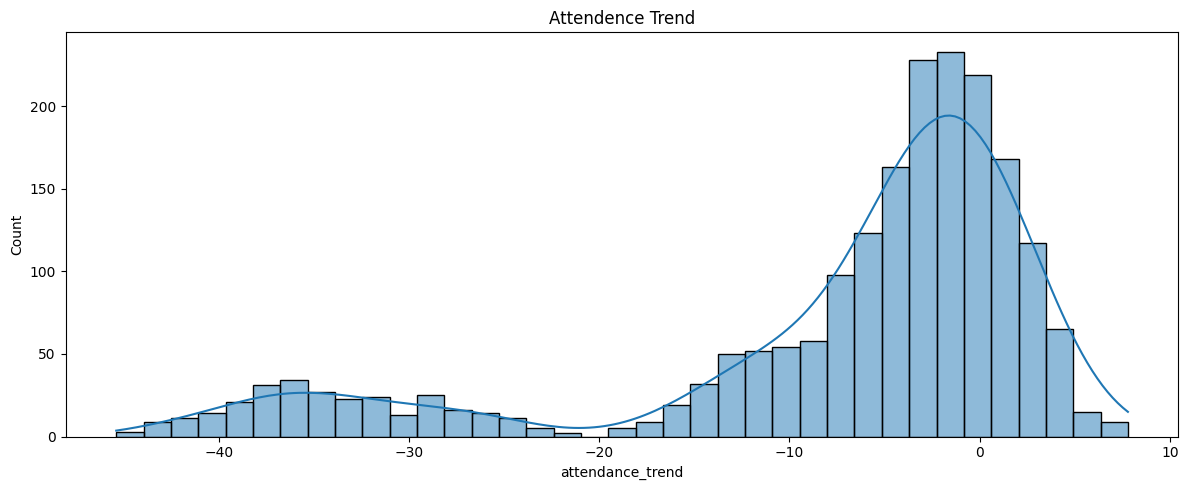

In [81]:
mp.figure(figsize=(12,5))
ss.histplot(data=df,x='attendance_trend',kde=True)
mp.title("Attendence Trend")
mp.tight_layout()

In [82]:
monthly_attendence = ['attendance_pct_Feb_2025','attendance_pct_Mar_2025','attendance_pct_Apr_2025',
                     'attendance_pct_May_2025','attendance_pct_Jun_2025','attendance_pct_Jul_2025']

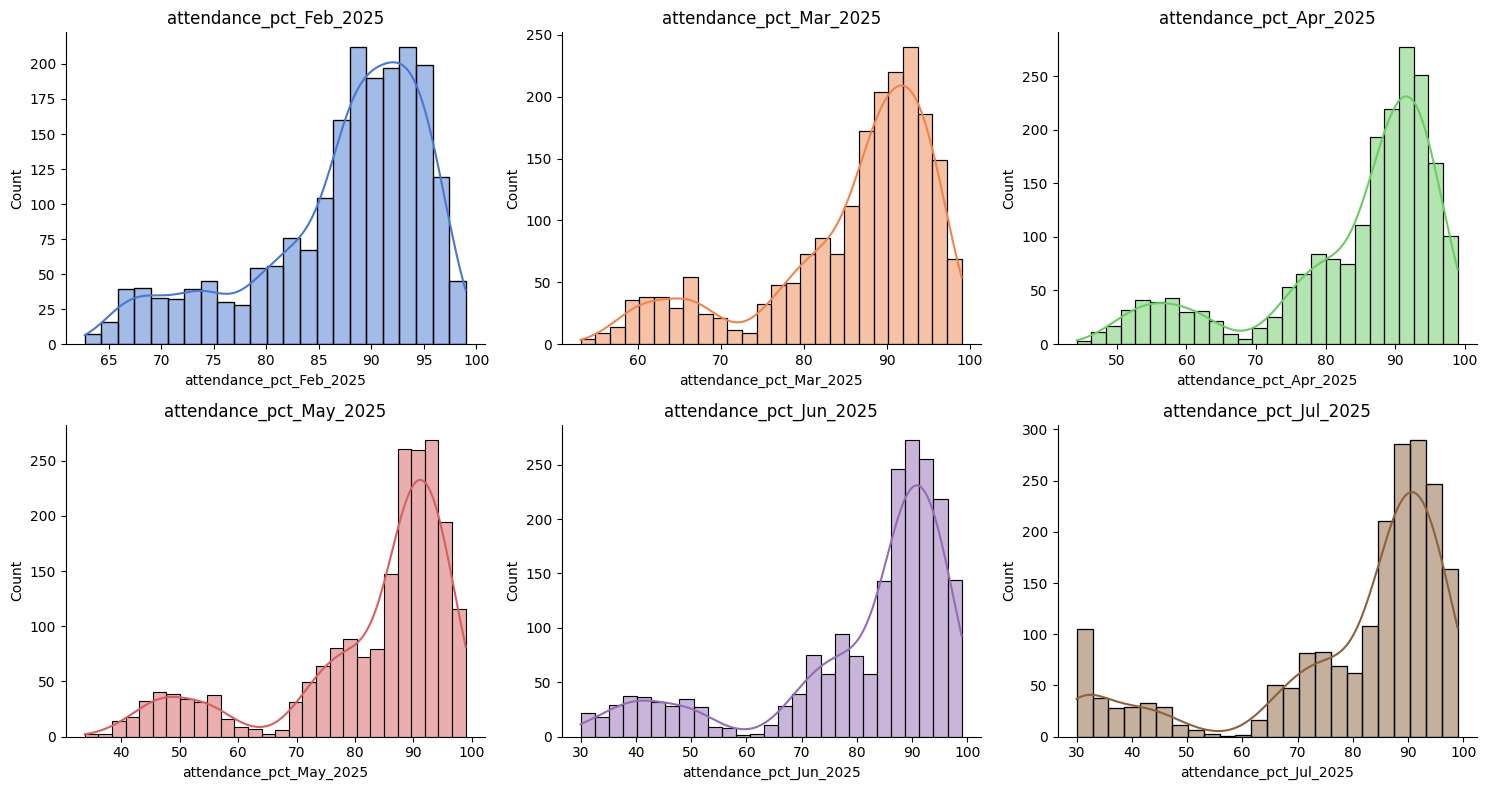

In [83]:
fig,ax = mp.subplots(2,3,figsize=(15,8))
colors = ss.color_palette("muted", 6)
for i,month in enumerate(monthly_attendence) : 
    row = i // 3
    col = i% 3
    
    ss.histplot(data=df,x=month,kde=True,ax=ax[row,col],color=colors[i])
    ax[row,col].set_title(month)
    ax[row, col].spines["top"].set_visible(False)
    ax[row, col].spines["right"].set_visible(False)
mp.tight_layout()

In [84]:
bins = [0, 50, 60, 70, 80, 90, 100]

In [85]:
attendance_risk = (df.groupby(pd.cut(df["avg_attendance_pct"], bins=bins),observed=True)["target"].mean() * 100)

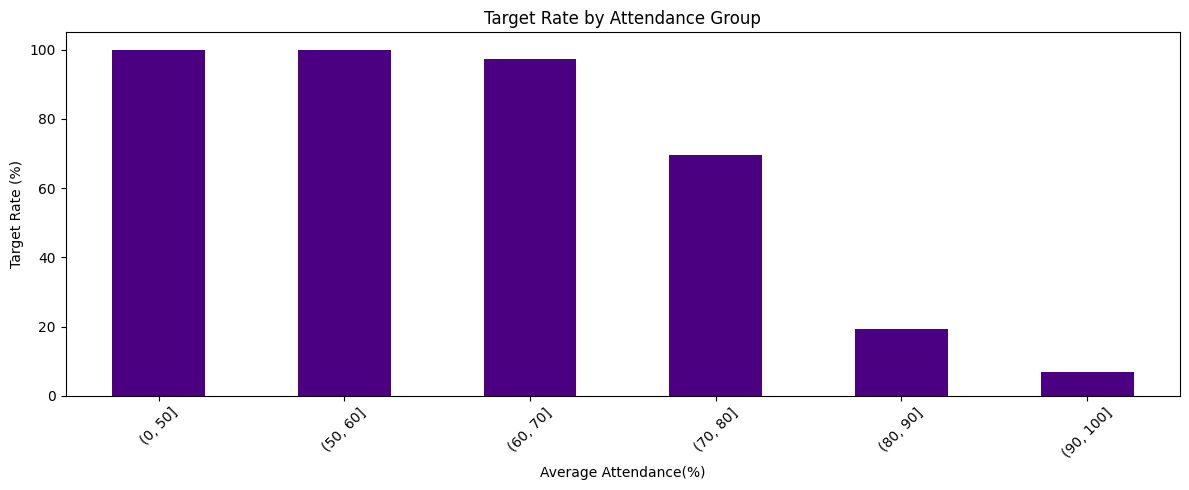

In [86]:
mp.figure(figsize=(12,5))
attendance_risk.plot(kind="bar",color="indigo")
mp.xlabel("Average Attendance(%)")
mp.ylabel("Target Rate (%)")
mp.title("Target Rate by Attendance Group")
mp.xticks(rotation=45)
mp.tight_layout()

In [87]:
scores = ['Accountancy_previous_score','Accountancy_latest_score','English_previous_score',
                  'English_latest_score','Business Studies_previous_score','Business Studies_latest_score',
                 'Chemistry_previous_score','Chemistry_latest_score','Computer Science_previous_score',
                  'Computer Science_latest_score','Mathematics_previous_score','Mathematics_latest_score',
                 'Physics_previous_score','Physics_latest_score','Economics_previous_score','Economics_latest_score']

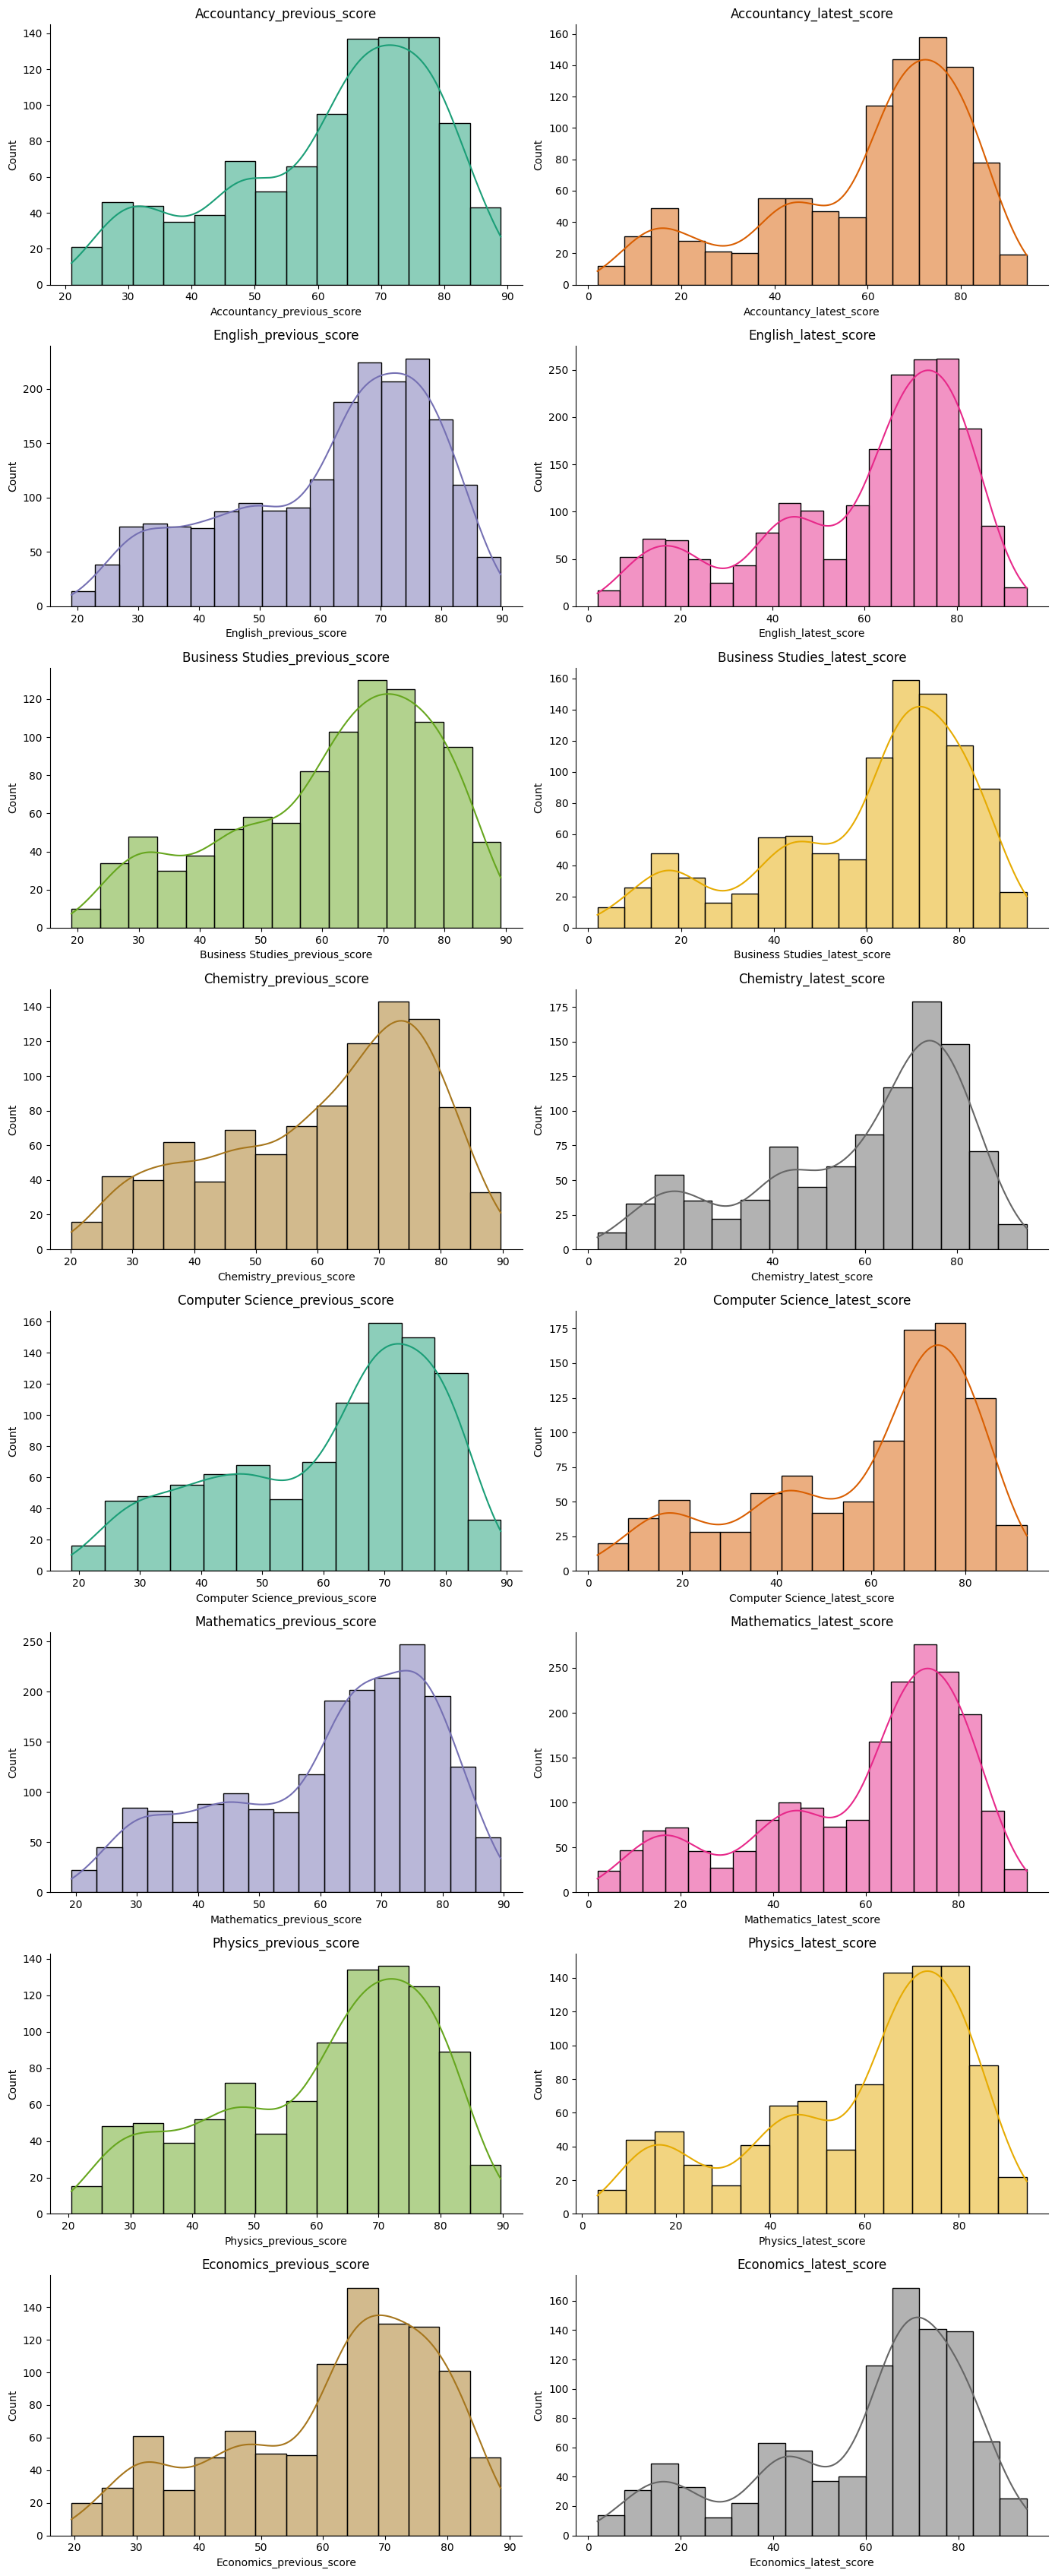

In [88]:
fig,ax = mp.subplots(8,2,figsize=(14,34))
colors = ss.color_palette("Dark2", 16)
for i,score in enumerate(scores) : 
    row = i // 2
    col = i% 2
    
    ss.histplot(data=df,x=score,kde=True,ax=ax[row,col],color=colors[i])
    ax[row,col].set_title(score)
    ax[row, col].spines["top"].set_visible(False)
    ax[row, col].spines["right"].set_visible(False)
mp.tight_layout()

In [89]:
result = ['Accountancy_attempts','Accountancy_result','English_attempts','English_result',
           'Business Studies_attempts','Business Studies_result','Chemistry_attempts','Chemistry_result',
           'Computer Science_attempts','Computer Science_result','Mathematics_attempts','Mathematics_result',
           'Physics_attempts','Physics_result','Economics_attempts','Economics_result']

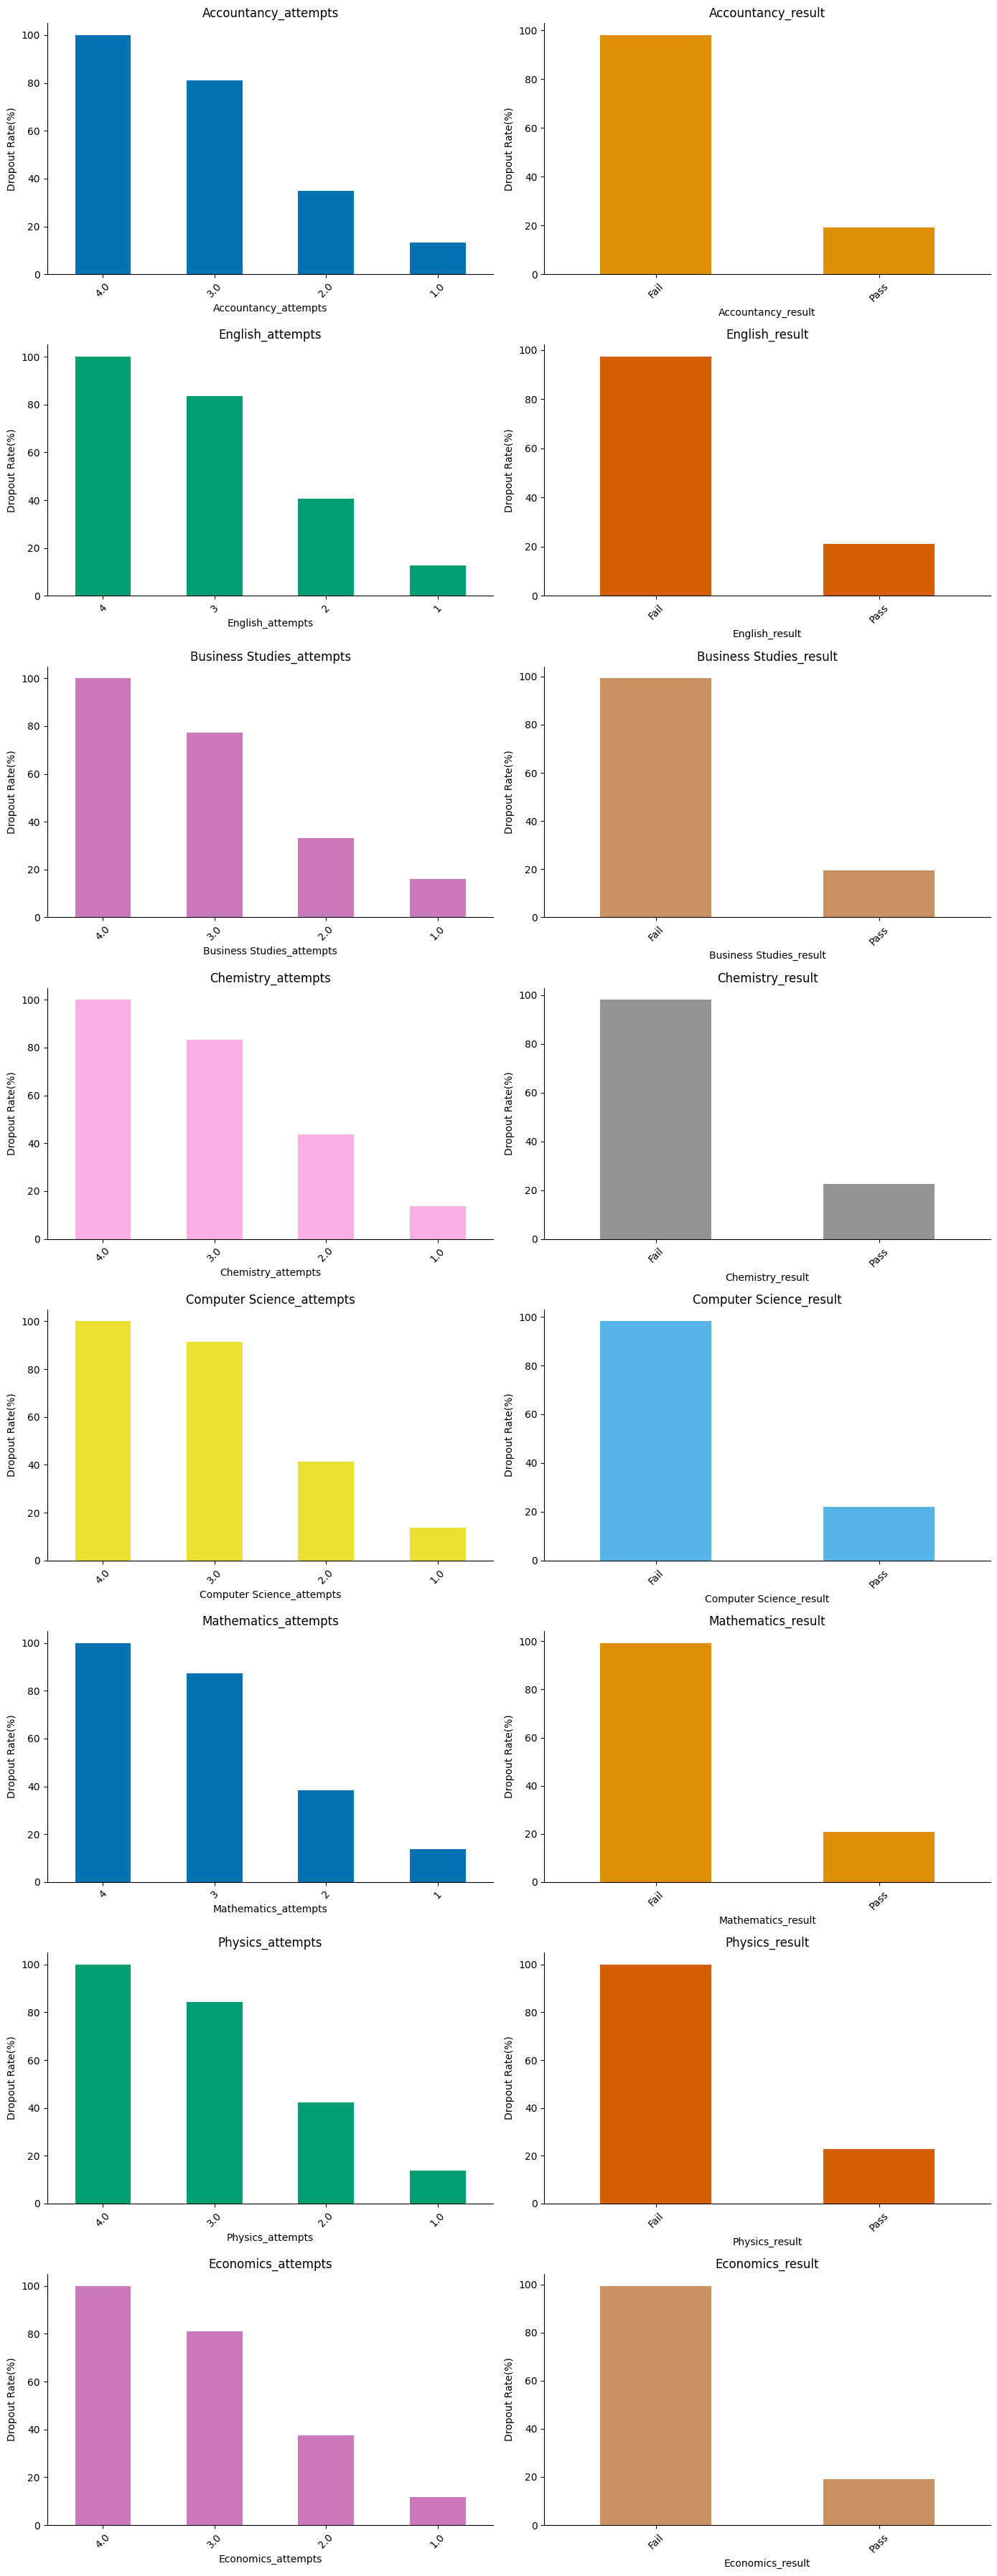

In [90]:
fig, ax = mp.subplots(8,2, figsize=(14, 36))
colors = ss.color_palette("colorblind", 16)

for i, col in enumerate(result):
    row = i // 2
    column = i % 2

    rate = df.groupby(col)["target"].mean().sort_values(ascending=False) * 100

    rate.plot(kind="bar", ax=ax[row, column],color=colors[i])

    ax[row, column].set_title(col)
    ax[row, column].set_xlabel(col)
    ax[row, column].set_ylabel("Dropout Rate(%)")
    ax[row, column].spines["top"].set_visible(False)
    ax[row, column].spines["right"].set_visible(False)
    ax[row, column].tick_params(axis='x', rotation=45)

mp.tight_layout()
mp.show()

In [91]:
sub_fail = df.groupby('subjects_failing_now')['target'].mean().sort_values()* 100

Text(108.34722222222221, 0.5, 'Dropout Rate')

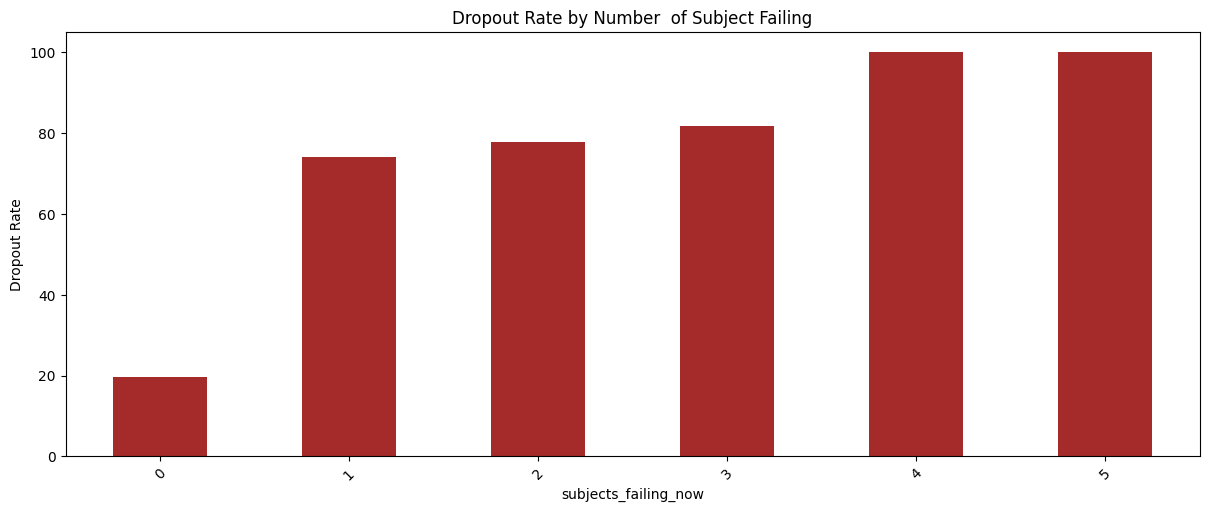

In [92]:
mp.figure(figsize=(12,5))
sub_fail.plot(kind="bar",color="brown")
mp.xticks(rotation=45)
mp.tight_layout()
mp.title("Dropout Rate by Number  of Subject Failing")
mp.ylabel("Dropout Rate")

In [93]:
avg = ['avg_score_previous','avg_score_latest','score_trend']

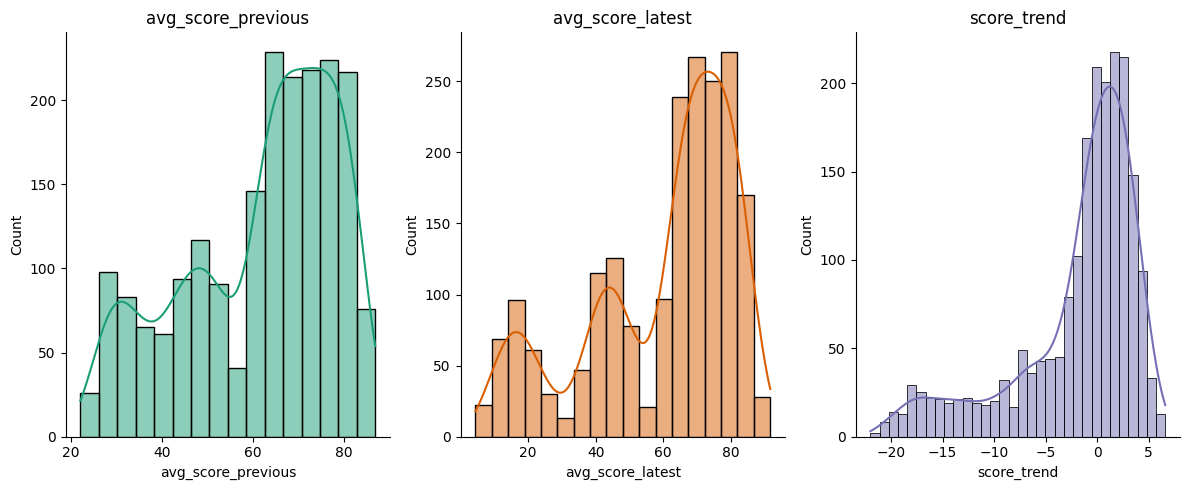

In [94]:
fig,ax = mp.subplots(1,3,figsize=(12,5))
colors = ss.color_palette("Dark2", 3)
for i,score in enumerate(avg) : 
    hist_color = colors[i]
    kde_color = tuple(c * 0.5 for c in hist_color)
    ss.histplot(data=df,x=score,kde=True,ax=ax[i],color=colors[i])
    ax[i].set_title(score)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
mp.tight_layout()

In [95]:
avg_score_cut = df.groupby(pd.cut(df["avg_score_latest"], bins=5))["target"].mean() * 100

C:\Users\01\AppData\Local\Temp\ipykernel_4820\3567722773.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_cut = df.groupby(pd.cut(df["avg_score_latest"], bins=5))["target"].mean() * 100


In [96]:
avg_trend_cut = df.groupby(pd.cut(df["score_trend"], bins=5))["target"].mean() * 100

C:\Users\01\AppData\Local\Temp\ipykernel_4820\219400267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_trend_cut = df.groupby(pd.cut(df["score_trend"], bins=5))["target"].mean() * 100


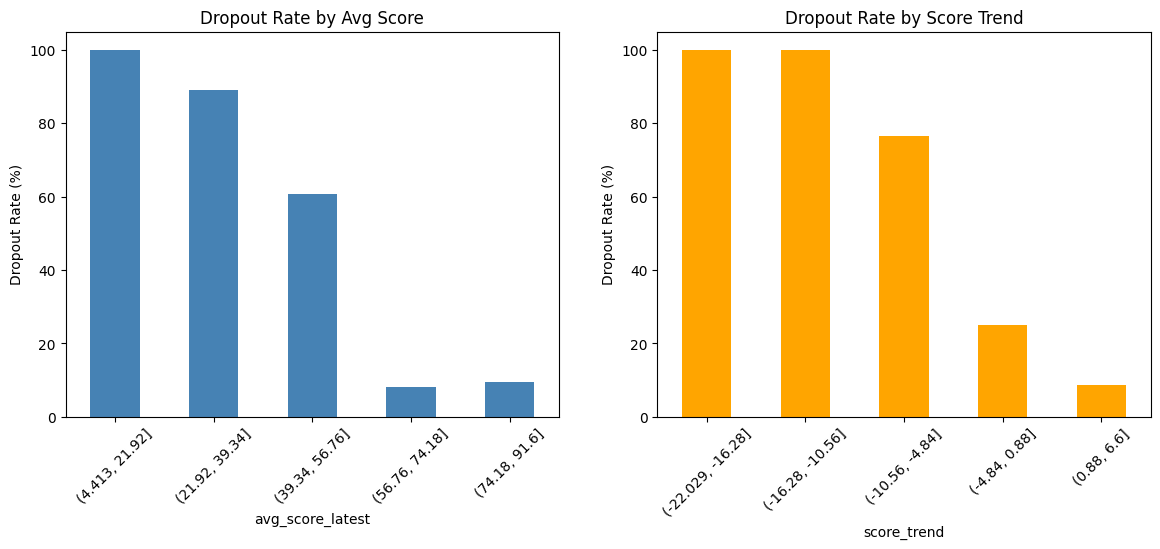

In [97]:
fig,ax = mp.subplots(1, 2, figsize=(14, 5))

avg_score_cut.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Dropout Rate by Avg Score")
ax[0].set_xlabel("avg_score_latest")
ax[0].set_ylabel("Dropout Rate (%)")
ax[0].tick_params(axis="x", rotation=45)

avg_trend_cut.plot(kind="bar", ax=ax[1], color="orange")
ax[1].set_title("Dropout Rate by Score Trend")
ax[1].set_xlabel("score_trend")
ax[1].set_ylabel("Dropout Rate (%)")
ax[1].tick_params(axis="x", rotation=45)

In [98]:
status = ['term1_status','term2_status','term3_status']

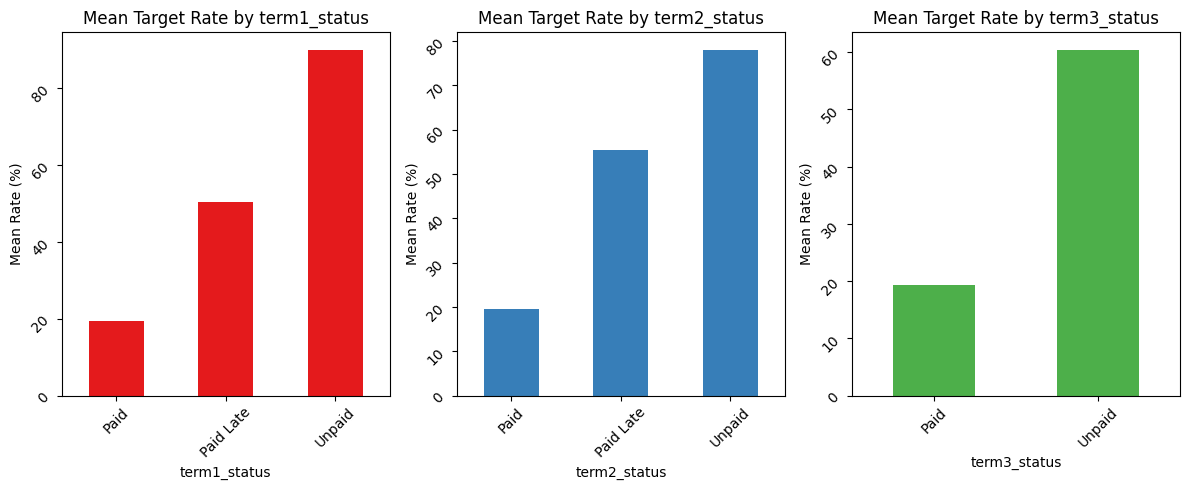

In [99]:
fig,ax = mp.subplots(1,3,figsize=(12,5))
colors = ss.color_palette("Set1", 3)
for i,col in enumerate(status) : 
    g = df.groupby(col)['target'].mean()*100
    g.plot(kind="bar",ax=ax[i],color=colors[i])

    ax[i].set_title(f"Mean Target Rate by {col}")
    ax[i].set_ylabel("Mean Rate (%)")
    ax[i].set_xlabel(col)
    ax[i].tick_params(rotation=45)
mp.tight_layout()

In [100]:
due = ['term1_days_overdue','term2_days_overdue','term3_days_overdue']

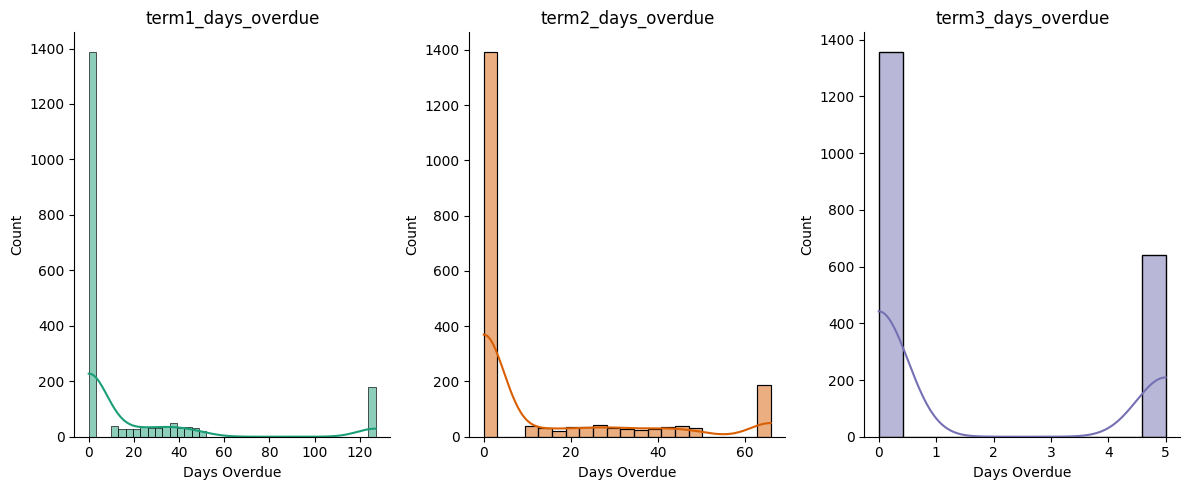

In [101]:
fig,ax = mp.subplots(1,3,figsize=(12,5))
colors = ss.color_palette("Dark2", 3)
for i,date in enumerate(due) : 
    ss.histplot(data=df,x=date,kde=True,ax=ax[i],color=colors[i])
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_title(date)
    ax[i].set_xlabel('Days Overdue')
mp.tight_layout()

In [102]:
labels = ['On Time', '1-7 Days', '8-30 Days', '31-60 Days', '60+ Days']

for col in due:
    df[col + '_group'] = pd.cut(
        df[col],
        bins=[-1, 0, 7, 30, 60, float('inf')],
        labels=labels
    )

In [103]:
long_df = pd.concat([
    df[['term1_days_overdue_group', 'target']]
        .rename(columns={'term1_days_overdue_group': 'overdue_group'})
        .assign(term='Term 1'),

    df[['term2_days_overdue_group', 'target']]
        .rename(columns={'term2_days_overdue_group': 'overdue_group'})
        .assign(term='Term 2'),

    df[['term3_days_overdue_group', 'target']]
        .rename(columns={'term3_days_overdue_group': 'overdue_group'})
        .assign(term='Term 3')
], ignore_index=True)

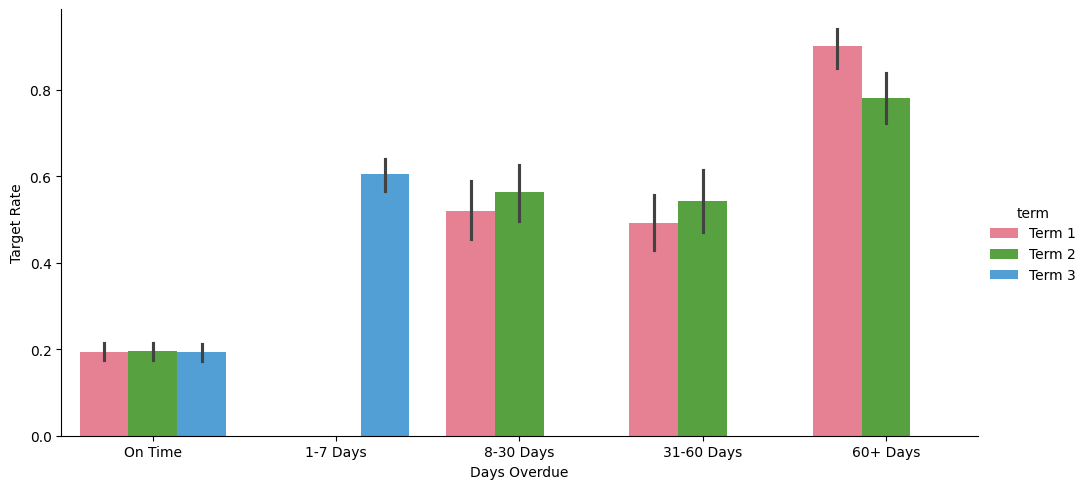

In [104]:
g = ss.catplot(data=long_df,x='overdue_group',y='target',hue='term',kind='bar',palette='husl',height=5,aspect=2,)
g.set_axis_labels('Days Overdue', 'Target Rate')

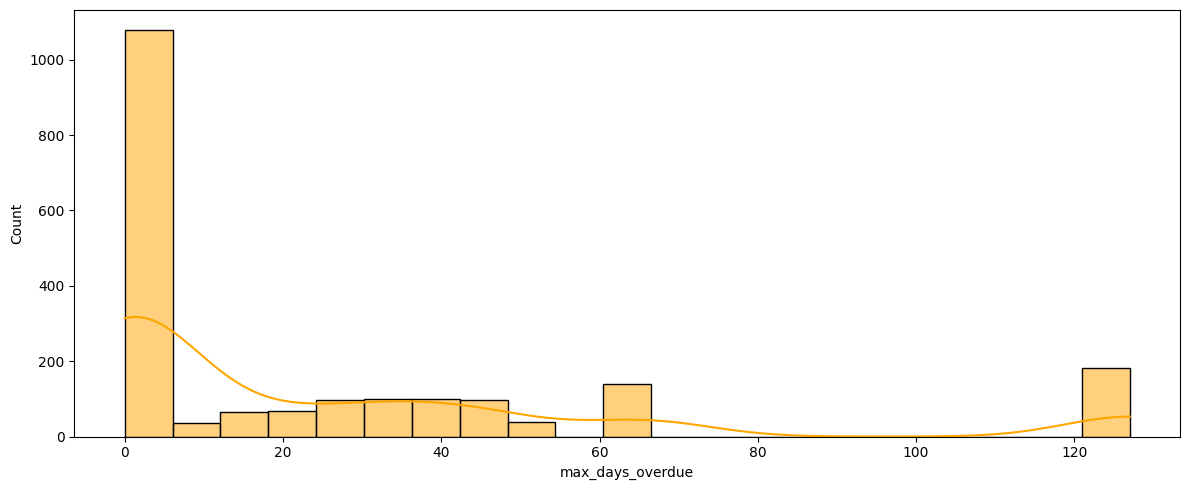

In [105]:
mp.figure(figsize=(12,5))
ss.histplot(data=df,x="max_days_overdue",kde=True,color="orange")
mp.tight_layout()

In [106]:
avg = ['avg_score_previous','avg_score_latest','score_trend']

MODEL BUILDING

In [107]:
from sklearn.model_selection import train_test_split

In [108]:
df.drop(columns=['dropped_out'],inplace=True)

In [109]:
df.drop(columns=['student_id','student_name','class_section','mentor_name','guardian_email','guardian_phone',
                 'stream','term1_payment_date','term2_payment_date','term3_payment_date',
                 'term1_days_overdue_group','term2_days_overdue_group','term3_days_overdue_group',
                'term1_due_date','term2_due_date','term3_due_date'],inplace=True)

In [110]:
x = df.drop(columns=['target'])
y = df['target']

In [111]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [112]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.compose import ColumnTransformer

In [113]:
result_col = ['Accountancy_result','Business Studies_result','Chemistry_result',
              'Computer Science_result','Physics_result','Economics_result']
result_num = [12,16,20,24,28,40]

In [114]:
attempt_col = ['Accountancy_attempts','Business Studies_attempts','Chemistry_attempts',
              'Computer Science_attempts','Physics_attempts','Economics_attempts']
attempt_num = [11,15,19,23,27,39]

In [115]:
score_col = [9,10,13,14,17,18,21,22,25,26,37,38]

In [116]:
obj_col = df.select_dtypes(include='object').columns.tolist()
num_col = df.select_dtypes(include='number').columns.tolist()
num_col = [c for c in num_col if c not in scores and c not in attempt_col and c != 'target']

In [117]:
res_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="constant", fill_value="Unknown")),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [118]:
std_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())])

In [119]:
trf1 = ColumnTransformer(transformers=[
    ('res_imp',res_pipe,result_col),
    ('att_imp',SimpleImputer(strategy="constant",fill_value=0),attempt_col),
    ('mark_imp',SimpleImputer(strategy="median",add_indicator=True),scores),
    ('std',std_pipe,num_col),
    ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False),obj_col)
],remainder='passthrough')

In [120]:
pipe = Pipeline([
    ('preprocessor', trf1),
    ('model', LogisticRegression())])

In [121]:
from sklearn.model_selection import GridSearchCV

In [122]:
param_tog_grid = [{
     'model': [LogisticRegression()],
     'model__C' : [0.01,0.1,1,10],
    'model__penalty' : ['l2'],
    'model__max_iter' : [100,150,200,250]
    },
    {
    'model' : [GradientBoostingClassifier(random_state=42)],
    'model__n_estimators' :  [150,100,50],
    'model__learning_rate' :[0.05,0.01,0.1],
    'model__max_depth' : [4,2,5],
    },
    {
    'model':[XGBClassifier(eval_metric='logloss',random_state=42)],
    'model__n_estimators':[100,50,150],
    'model__learning_rate':[0.05,0.01,0.1],
    'model__max_depth':[4,5,2]
    }
       ]

In [123]:
grid = GridSearchCV(pipe,param_grid=param_tog_grid,cv=5,scoring="recall",n_jobs=-1)

In [124]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LogisticRegression()], 'model__C': [0.01, 0.1, ...], 'model__max_iter': [100, 150, ...], 'model__penalty': ['l2']}, {'model': [GradientBoost...ndom_state=42)], 'model__learning_rate': [0.05, 0.01, ...], 'model__max_depth': [4, 2, ...], 'model__n_estimators': [150, 100, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value

In [125]:
grid.best_params_

{'model': GradientBoostingClassifier(random_state=42),
 'model__learning_rate': 0.05,
 'model__max_depth': 5,
 'model__n_estimators': 150}

In [126]:
final_model = grid.best_estimator_

In [127]:
grid.best_score_

np.float64(0.75)

In [128]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report

In [129]:
y_prob = final_model.predict_proba(x_test)[:, 1]

In [130]:
thre = []
for threshold in np.arange(0.20, 0.61, 0.05):

    y_pred_threshold = (y_prob >= threshold).astype(int)

    thre.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1 Score': f1_score(y_test, y_pred_threshold)
    })

In [131]:
threshold_table = pd.DataFrame(thre)

threshold_table

,Threshold,Precision,Recall,F1 Score
0,0.20,0.722973,0.823077,0.769784
1,0.25,0.751825,0.792308,0.771536
2,0.30,0.786260,0.792308,0.789272
3,0.35,0.798450,0.792308,0.795367
4,0.40,0.814516,0.776923,0.795276
5,0.45,0.837607,0.753846,0.793522
6,0.50,0.842105,0.738462,0.786885
7,0.55,0.853211,0.715385,0.778243
8,0.60,0.846154,0.676923,0.752137


In [132]:
threshold = 0.4

In [133]:
y_pred = (y_prob >= threshold).astype(int)

MODEL EVALUATION

In [134]:
predict = grid.predict(x_test)

In [135]:
cmm = confusion_matrix(y_test,y_pred)

Text(0.5, 1.0, 'Confusion Matrix')

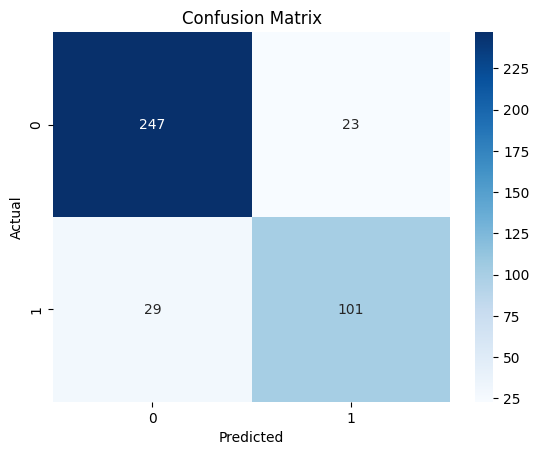

In [136]:
ss.heatmap(cmm, annot=True, fmt='d', cmap='Blues')

mp.xlabel("Predicted")
mp.ylabel("Actual")
mp.title("Confusion Matrix")

In [137]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       270
           1       0.81      0.78      0.80       130

    accuracy                           0.87       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.87      0.87      0.87       400



In [138]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.87
Precision: 0.8145161290322581
Recall   : 0.7769230769230769
F1 Score : 0.7952755905511811


In [139]:
roc_auc = roc_auc_score(y_test, y_prob)

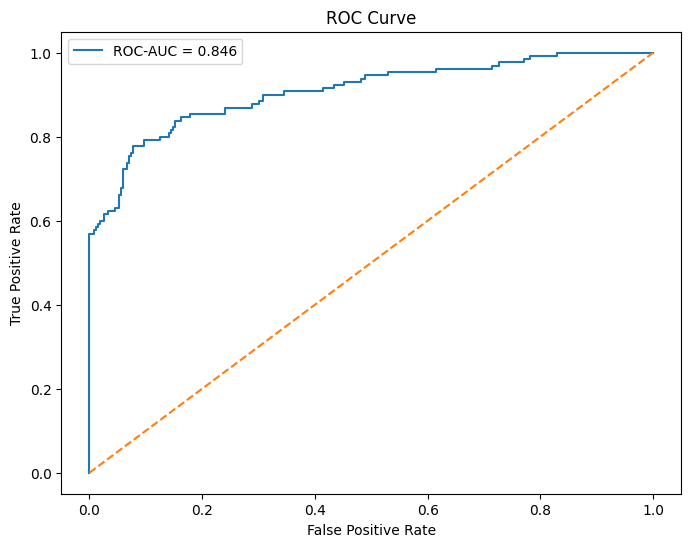

In [140]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_pred)

mp.figure(figsize=(8, 6))

mp.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
mp.plot([0, 1], [0, 1], linestyle='--')

mp.xlabel("False Positive Rate")
mp.ylabel("True Positive Rate")
mp.title("ROC Curve")
mp.legend()

FEATURE IMPORTANCE

In [141]:
preprocessor = final_model.named_steps['preprocessor']
model = final_model.named_steps['model']

In [142]:
feature_names = preprocessor.get_feature_names_out()

In [143]:
importance = model.feature_importances_

In [144]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance}).sort_values('Importance',ascending=False)

In [145]:
def get_original_feature(name):

    name = name.split('__')[-1]

    for col in obj_col:
        if name.startswith(col + '_'):
            return col

    for col in scores:
        if name.startswith(col + '_missing'):
            return col

    return name

In [146]:
feature_importance['Original_Feature'] = (feature_importance['Feature'].apply(get_original_feature))


In [147]:
feature_importance = (
    feature_importance
    .groupby('Original_Feature')['Importance'].sum().sort_values(ascending=False).reset_index())

In [148]:
feature_importance.columns = ['Feature', 'Importance']

In [149]:
top15 = feature_importance.head(15).sort_values('Importance',ascending=True)

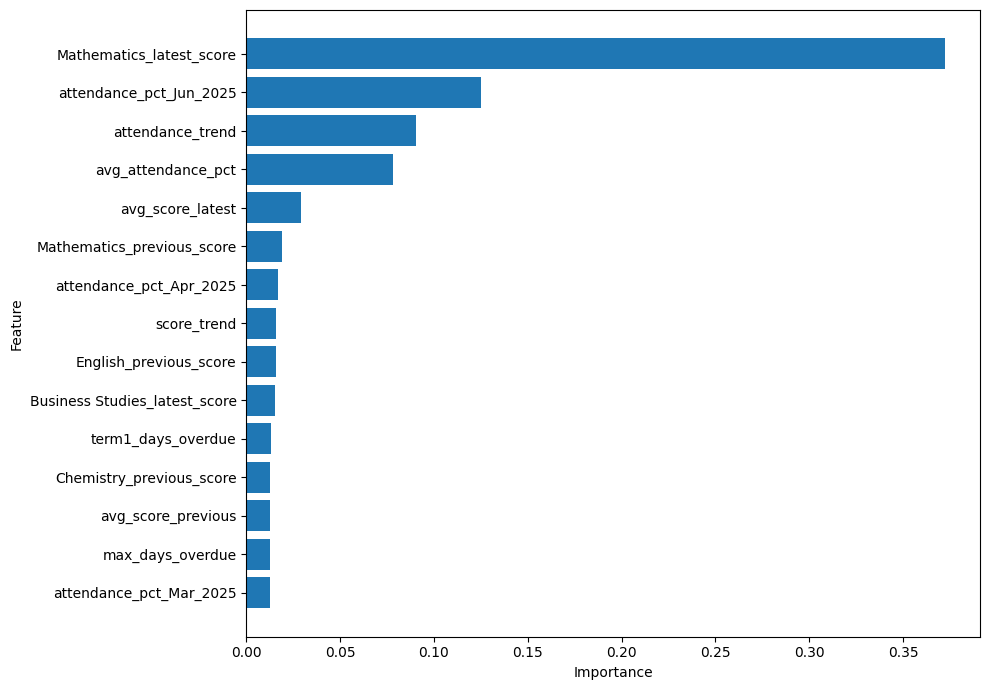

In [150]:
mp.figure(figsize=(10, 7))
mp.barh(top15['Feature'],top15['Importance'])
mp.xlabel("Importance")
mp.ylabel("Feature")
mp.tight_layout()

In [151]:
import joblib

SHAP

In [152]:
x_test_transformed = preprocessor.transform(x_test)

In [153]:
explainer = shap.TreeExplainer(model)

In [154]:
shap_values = explainer.shap_values(x_test_transformed)

In [155]:
shap_values[10,5] # 10 ma students nu 5th mu features

np.float64(0.00013724515482946298)

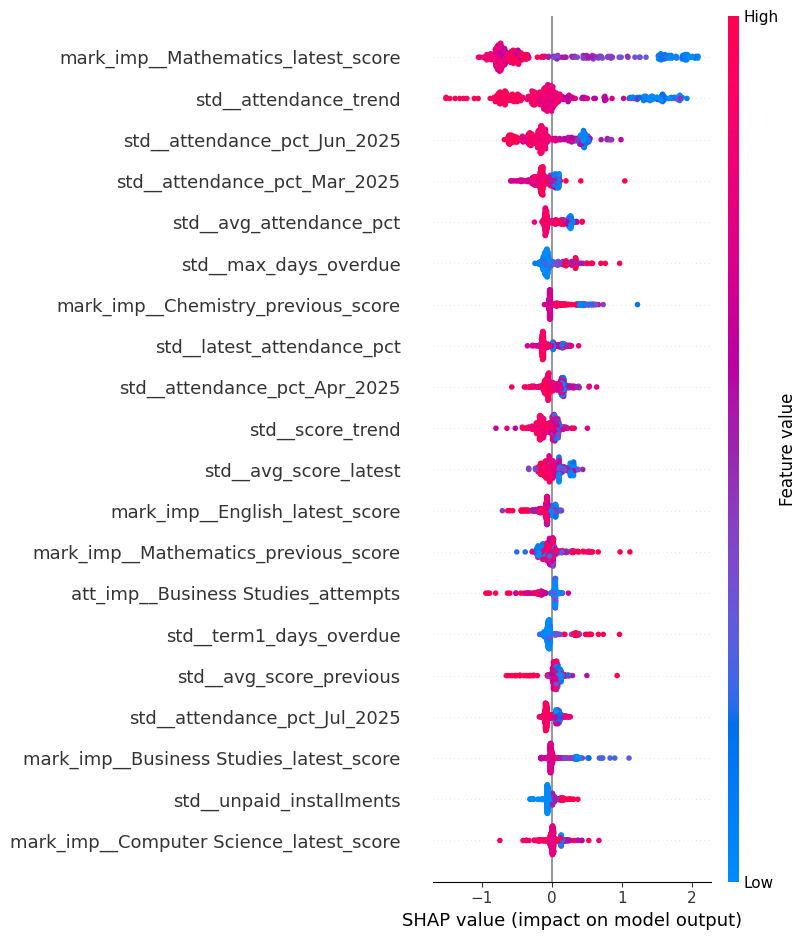

In [156]:
shap.summary_plot(shap_values,x_test_transformed,feature_names=feature_names)

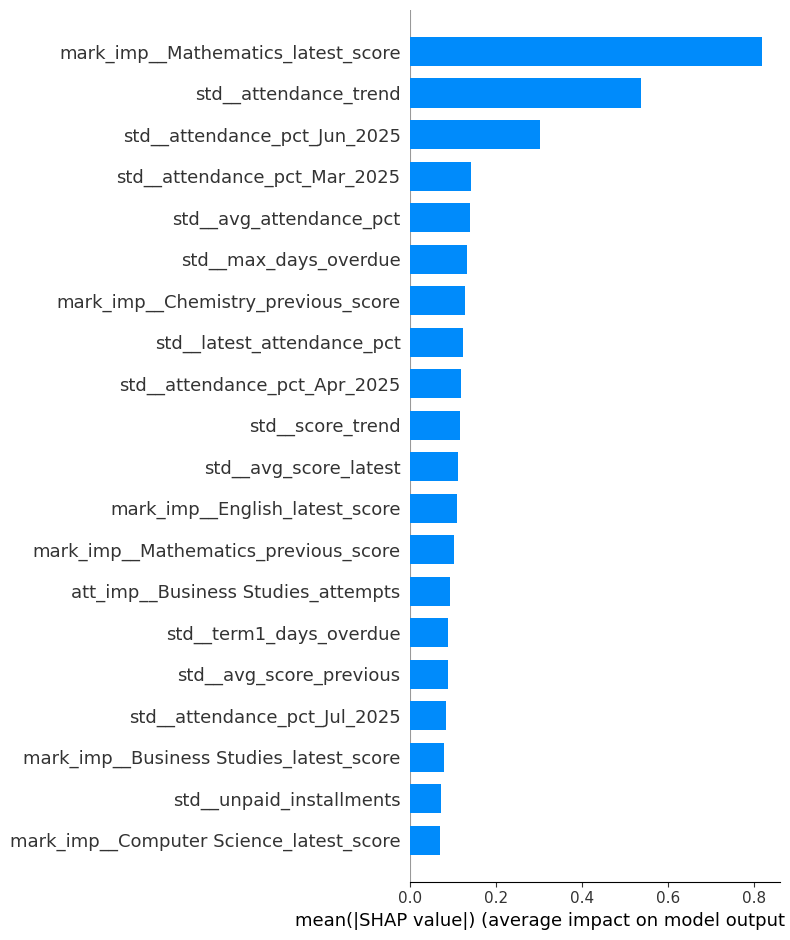

In [157]:
shap.summary_plot(shap_values,x_test_transformed,feature_names=feature_names,plot_type="bar")

In [158]:
student_index = 15

In [159]:
stu_prob = final_model.predict_proba(x_test.iloc[[student_index]])[:,1][0]

In [160]:
print(f"Student index : {student_index}")
print(f"Student Dropout Probability : {stu_prob}")

Student index : 15
Student Dropout Probability : 0.03247077882829897


In [161]:
stu_explain = shap.Explanation(values=shap_values[student_index],
                               base_values=explainer.expected_value,
                              data=x_test_transformed[student_index],feature_names=feature_names)

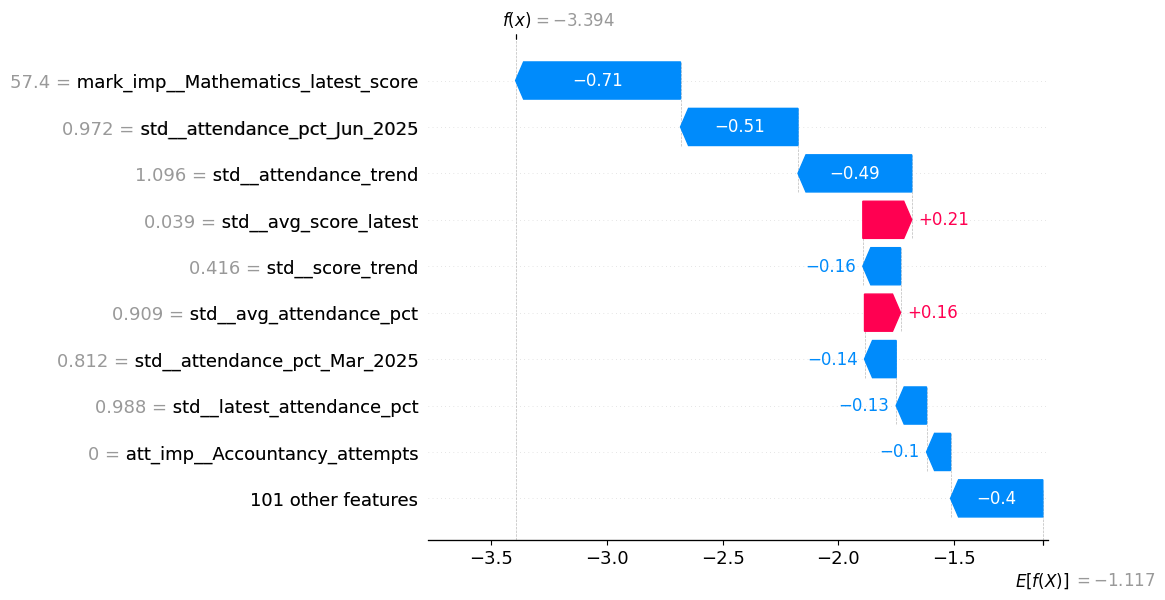

In [162]:
shap.waterfall_plot(stu_explain) ##f(x) -> avergae predication

In [163]:
 student_shap = pd.DataFrame({
     'Feature' : feature_names,
     'shap values' : shap_values[student_index],
     'Feature value' : x_test_transformed[student_index]
 })

In [164]:
student_shap['abs_shap'] = (student_shap['shap values'].abs())

In [165]:
student_shap = student_shap.sort_values('abs_shap',ascending=False)

In [166]:
risk_increasing = student_shap[student_shap['shap values']>0].head(5)

In [167]:
risk_increasing

,Feature,shap values,Feature value,abs_shap
67,std__avg_score_latest,0.211249,0.039441,0.211249
58,std__avg_attendance_pct,0.155666,0.909162,0.155666
33,mark_imp__Computer Science_latest_score,0.076133,65.000000,0.076133
19,att_imp__Business Studies_attempts,0.053892,0.000000,0.053892
65,std__max_attempts_any_subject,0.038706,-0.274825,0.038706


In [168]:
risk_decreasing = student_shap[student_shap['shap values']<0].sort_values('shap values',ascending=True).head(5)

In [169]:
risk_decreasing

,Feature,shap values,Feature value,abs_shap
35,mark_imp__Mathematics_latest_score,-0.712321,57.400000,0.712321
56,std__attendance_pct_Jun_2025,-0.507382,0.972389,0.507382
60,std__attendance_trend,-0.491323,1.095838,0.491323
68,std__score_trend,-0.162900,0.416377,0.162900
53,std__attendance_pct_Mar_2025,-0.136806,0.812285,0.136806


In [170]:
student_shap['Original Feature'] = student_shap['Feature'].apply(get_original_feature)

In [171]:
student_shap = student_shap[['Feature','Original Feature','Feature value','shap values','abs_shap']]

In [172]:
joblib.dump(final_model,"student_risk_model_previous.pkl")

['student_risk_model_previous.pkl']

In [173]:
joblib.dump(threshold,"threshold.pkl")

['threshold.pkl']

In [115]:
joblib.dump(scores, "scores.pkl")

['scores.pkl']

In [116]:
joblib.dump(obj_col, "obj_col.pkl")

['obj_col.pkl']

In [117]:
joblib.dump(attempt_col, "attempt_col.pkl")

['attempt_col.pkl']

In [118]:
joblib.dump(result_col, "result_col.pkl")

['result_col.pkl']

In [119]:
expected_columns = x_train.columns.tolist()

In [120]:
joblib.dump(expected_columns, "expected_columns.pkl")

['expected_columns.pkl']